The **pix2pix** architecture is a Conditional GAN (cGAN) designed for supervised image-to-image translation. In this notebook, it is trained to generate synthetic realistic images starting from segmentation masks, facilitating the creation of augmented hybrid datasets aimed at improving the performance of YOLOv8.

# IMPORTS
Importing the necessary libraries and repos from GitHub. The used datasets here were DENTEX and UFBA, both improved with SAM (Segment Anything Model).


In [ ]:
import numpy as np 
import pandas as pd
import os

# Import Data Inputs
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
 
# Import and download datasets
!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1fZ50wTtaxjBvq9VKejMjlIheWDUVx-DX -O ./data/ # pix2pix dataset


# pix2pix repo cloning and requirement.txt install
if not os.path.exists('/kaggle/working/pytorch-CycleGAN-and-pix2pix'):
    !git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
!pip install dominate visdom wandb

# DATASET PRE-PROCESSING
In order to train a pix2pix model it's necessary to associate each mask with its image in the same img. 

The following cell modifies the images and their labels, then creates a png mask file.


In [ ]:
import cv2
import numpy as np
import os
from tqdm import tqdm
import zipfile
from pathlib import Path

def img_lbl_coupling(img_path, label_txt_path, output_path, img_res=256):
    # Takes an image, its YOLO label and it generates the mask. 
    # Applies cropping if necessary, rescales to 256x256 and it creates an image that's the mask.png and its image one next the other
    
    img = cv2.imread(img_path)  # Load the original image
    if img is None:
        return False 

    h, w = img.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8) #  # Creates an empty mask

    # It reads the YOLO file and it creates the polygons
    if os.path.exists(label_txt_path):
        with open(label_txt_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                data = line.strip().split()
                if len(data) < 3:
                    continue

                # vertices reconstruction and denormalization
                coords = np.array(data[1:], dtype=np.float32).reshape(-1, 2)
                coords[:, 0] *= w
                coords[:, 1] *= h
                coords = coords.astype(np.int32)

                # It fills the empty mask with the white teeth polygons
                cv2.fillPoly(mask, [coords], color=255)
    else:
        # Empty image
        pass

    # Check format and cropping
    if h == w:
        # Its already a squared image (UFBA)
        img_cropped = img
        mask_cropped = mask
    else:
        # Its not squared (DENTEX), it applies cropping to obtain a squared image
        margin_h = int(h * 0.022)
        lato_quadrato = h - (2 * margin_h)
        margin_w = int((w - lato_quadrato) / 2)

        img_cropped = img[margin_h : margin_h + lato_quadrato, margin_w : margin_w + lato_quadrato]
        mask_cropped = mask[margin_h : margin_h + lato_quadrato, margin_w : margin_w + lato_quadrato]

    # Downsample to 256x256
    # INTER_AREA interpolation for image quality. INTER_NEAREST interpolation for mask accuracy
    img_resized = cv2.resize(img_cropped, (img_res, img_res), interpolation=cv2.INTER_AREA)
    mask_resized = cv2.resize(mask_cropped, (img_res, img_res), interpolation=cv2.INTER_NEAREST)

    # PIX2PIX formatting (A + B)
    # It converts the mask to RGB and pastes it to the left of its image
    mask_resized_3c = cv2.cvtColor(mask_resized, cv2.COLOR_GRAY2BGR)
    pix2pix_ready_img = np.hstack((mask_resized_3c, img_resized))

    # Saving the image
    cv2.imwrite(output_path, pix2pix_ready_img)
    return True


def dataset_process(cartella_immagini, cartella_labels, cartella_output, risoluzione_target=256):  #It reads all of the images in a folder, looks for the YOLO labels and saves the image-mask couples.
    os.makedirs(cartella_output, exist_ok=True)

    valid_ext = ('.jpg', '.jpeg', '.png')
    img_list = [f for f in os.listdir(cartella_immagini) if f.lower().endswith(valid_ext)]

    processed_img = 0
    errors = 0

    for nome_img in tqdm(img_list, desc=f"Elaboration in progress"):
        img_path = os.path.join(cartella_immagini, nome_img)

        nome_base = os.path.splitext(nome_img)[0]
        label_txt_path = os.path.join(cartella_labels, f"{nome_base}.txt")
        output_path = os.path.join(cartella_output, f"{nome_base}_pix2pix.png")

        successo = img_lbl_coupling(img_path, label_txt_path, output_path, img_res=risoluzione_target)

        if successo:
            processed_img += 1
        else:
            errors += 1

    print(f" -> Couples Generated: {processed_img} | Errors: {errors}")


#Original dataset PATH
ZIP_file = '/kaggle/working/data/pix2pix/QE_sam.zip'

DATASET_ROOT_ORIGINALE = '/kaggle/working/data/pix2pix/QE_sam'

with zipfile.ZipFile(ZIP_file, 'r') as zip_ref:
    zip_ref.extractall(DATASET_ROOT_ORIGINALE)

#NEW DATASET (PIX2PIX format) PATH
DATASET_ROOT_PIX2PIX = '/kaggle/working/QEM512_pix2pix_256'

RISOLUZIONE_GAN = 256

# iteration in train and val directories
for split in ['train', 'val']:
    print(f" PREPARING SPLIT: {split.upper()}")

    dir_immagini_input = os.path.join(DATASET_ROOT_ORIGINALE, 'images', split)
    dir_labels_input = os.path.join(DATASET_ROOT_ORIGINALE, 'labels', split)

    dir_output_pix2pix = os.path.join(DATASET_ROOT_PIX2PIX, split)

    if os.path.exists(dir_immagini_input):
        dataset_process(
            cartella_immagini=dir_immagini_input,
            cartella_labels=dir_labels_input,
            cartella_output=dir_output_pix2pix,
            risoluzione_target=RISOLUZIONE_GAN
        )
    else:
        print(f"WARNING: The {dir_immagini_input} folder doesn't exist.")

print("\nDATASET CONVERSION COMPLETE")
print(f"Dataset Pix2Pix is ready in: {DATASET_ROOT_PIX2PIX}")

# TRAINING

In [ ]:
os.chdir('/kaggle/working/pytorch-CycleGAN-and-pix2pix')
%cd /kaggle/working/pytorch-CycleGAN-and-pix2pix

!torchrun --nproc_per_node=2 train.py \
  --dataroot /kaggle/working/QEM512_pix2pix_256 \
  --name xray_pix2pix_256 \
  --model pix2pix \
  --direction AtoB \
  --batch_size 8 \
  --preprocess none \
  --norm instance \
  --save_epoch_freq 10 \
  --n_epochs 100 \
  --n_epochs_decay 100

# RESULTS
**epoch 1** : mask, real, fake
\
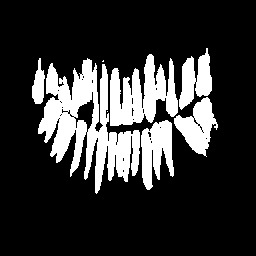
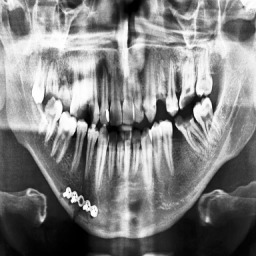
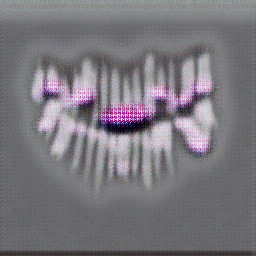


**epoch 350** : mask, real, fake
\
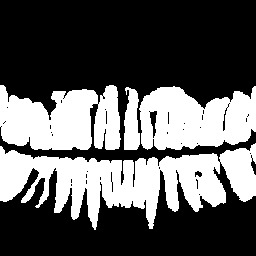
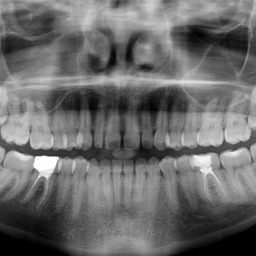
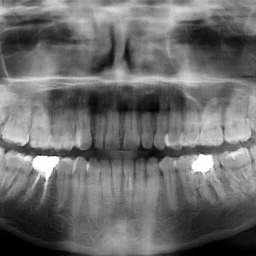
